
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

errores
Error con N =  2: 0.010896
Error con N =  4: 0.002770
Error con N = 10: 0.000448


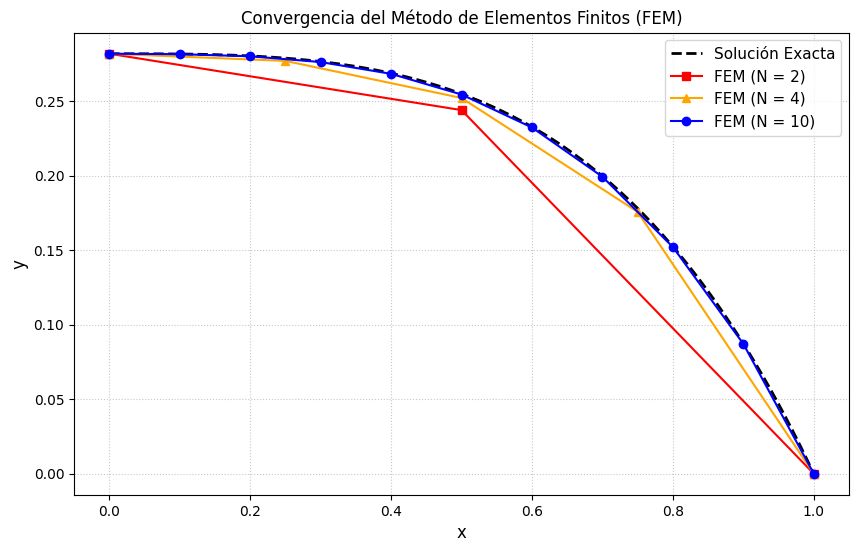

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def fem_1d(f, a, b, ya, yb, N):
    x = np.linspace(a, b, N + 1)
    h = (b - a) / N
    alpha = np.zeros((N + 1, N + 1))
    B = np.zeros(N + 1)
    for n in range(N):
        i, j = n, n+1

        alpha[i, i] += 1/h
        alpha[i, j] += -1/h
        alpha[j,i] += -1/h
        alpha[j, j] += 1/h

        B[i] += f(x[i]) * h / 2
        B[j] += f(x[j]) * h / 2

    for i in range(1, N):
        B[i] -= alpha[i,0] * ya
        B[i] -= alpha[i, N] * yb

    alpha_int = alpha[1:N, 1:N]
    B_int = B[1:N]
    y_int=np.linalg.solve(alpha_int, B_int)

    y = np.zeros(N+ 1)
    y[0], y[N] = ya, yb
    y[1:N] =y_int

    return x, y

f = lambda x: x * np.exp(x)
a, b = 0, 1
ya, yb = 3 - np.e, 0
def y_exacta(x):
    return (2 - x) * np.exp(x) - x + (1 - np.e)
plt.close('all')
plt.figure(figsize=(10, 6))
x_fino = np.linspace(a, b, 200)
plt.plot(x_fino, y_exacta(x_fino), 'k--', linewidth=2, label='Solución Exacta')

valores_N = [2, 4, 10]
colores = ['red', 'orange', 'blue']
marcadores = ['s', '^', 'o']
print("errores")
for N, color, marcador in zip(valores_N, colores, marcadores):
    x, y = fem_1d(f, a, b, ya, yb, N)

    etiqueta = f'FEM (N = {N})'
    plt.plot(x, y, color=color, marker=marcador, linestyle='-', label=etiqueta)

    error = np.max(np.abs(y - y_exacta(x)))
    print(f"Error con N = {N:2d}: {error:.6f}")
plt.title('Convergencia del Método de Elementos Finitos (FEM)')
plt.legend(fontsize=11)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()